In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("sleppyfish/aircraft-classification-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 305M/305M [00:02<00:00, 121MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sleppyfish/aircraft-classification-dataset/versions/1
Contents of base_path (/root/.cache/kagglehub/datasets/sleppyfish/aircraft-classification-dataset/versions):
['1']
Contents of path (/root/.cache/kagglehub/datasets/sleppyfish/aircraft-classification-dataset/versions/1):
['test', 'train']


### Dataset Overview

Let's examine the structure of the downloaded dataset and display some sample images from the `train` and `test` directories.

In [ ]:
print(f"Contents of the 'train' directory: {os.listdir(os.path.join(path, 'train'))}")
print(f"Contents of the 'test' directory: {os.listdir(os.path.join(path, 'test'))}")

Contents of the 'train' directory: ['9', '3', '7', '8', '4', '5', '6', '1', '2']
Contents of the 'test' directory: ['9', '3', '7', '8', '4', '5', '6', '1', '2']


### Displaying Sample Images

Now, let's visualize a few sample images from the 'train' and 'test' datasets to get a better understanding of the image content.


--- Sample Images from Training Dataset (/root/.cache/kagglehub/datasets/sleppyfish/aircraft-classification-dataset/versions/1/train) ---
Found 19569 images in /root/.cache/kagglehub/datasets/sleppyfish/aircraft-classification-dataset/versions/1/train. Displaying 6 samples:


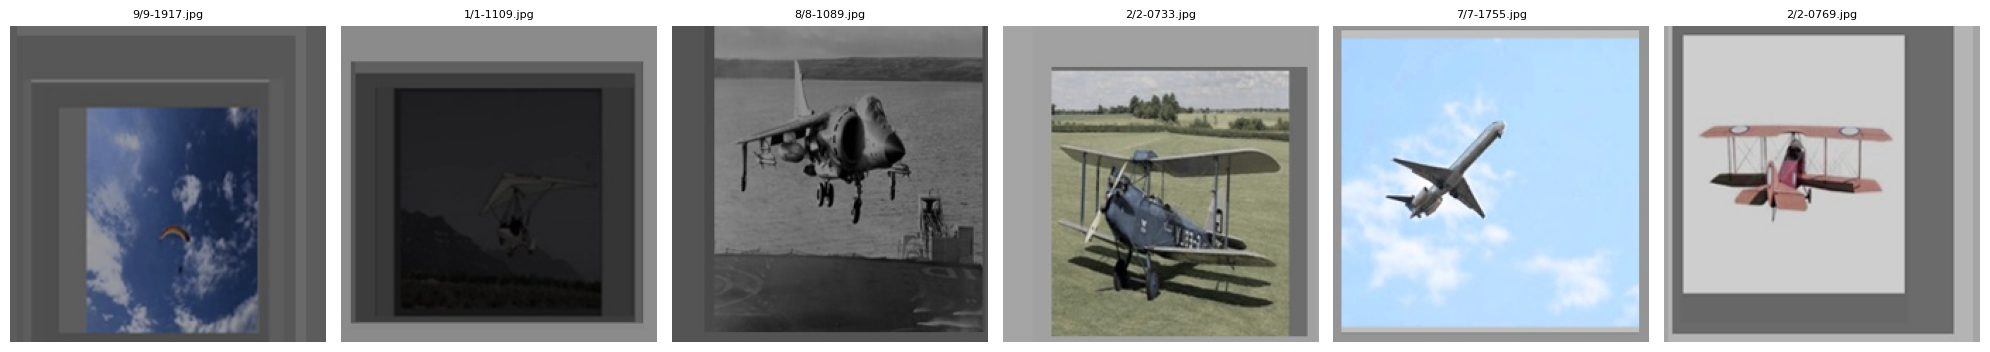


--- Sample Images from Test Dataset (/root/.cache/kagglehub/datasets/sleppyfish/aircraft-classification-dataset/versions/1/test) ---
Found 2305 images in /root/.cache/kagglehub/datasets/sleppyfish/aircraft-classification-dataset/versions/1/test. Displaying 6 samples:


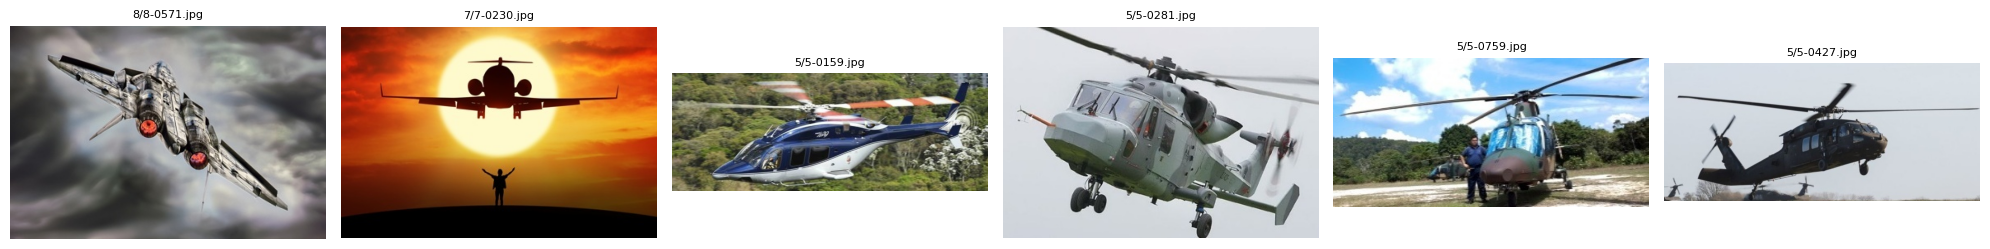

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images in {dataset_path}. Displaying {min(num_samples, len(all_image_paths))} samples:")

    # Select random samples to display
    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]
    elif len(samples_to_display) == 0:
        plt.close(fig) # Close empty figure if no samples
        return

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            axes[i].set_title(os.path.basename(os.path.dirname(img_path)) + '/' + os.path.basename(img_path), fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Display sample images from the 'train' directory
train_path = os.path.join(path, 'train')
print(f"\n--- Sample Images from Training Dataset ({train_path}) ---")
display_sample_images(train_path)

# Display sample images from the 'test' directory
test_path = os.path.join(path, 'test')
print(f"\n--- Sample Images from Test Dataset ({test_path}) ---")
display_sample_images(test_path)

In [ ]:
import tensorflow as tf

# Check if GPU is available
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('GPU device not found. Please enable GPU in Notebook Settings.')
else:
  print(f'Found GPU at: {device_name}')

# List physical devices
print("Physical Devices:", tf.config.list_physical_devices())


Found GPU at: /device:GPU:0
Physical Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Constants
IMG_SIZE = (299, 299)
BATCH_SIZE = 32
NUM_CLASSES = 9
EPOCHS = 10

# Data augmentation and loading
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Build InceptionV3 model
with tf.device('/device:GPU:0'):
    base_model = InceptionV3(weights='imagenet', include_top=False)
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='relu')(x)
    predictions = Dense(NUM_CLASSES, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)

    # Freeze early layers
    for layer in base_model.layers:
        layer.trainable = False

    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Model Summary
model.summary()

Found 15657 images belonging to 9 classes.
Found 3912 images belonging to 9 classes.
Found 2305 images belonging to 9 classes.
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, None,      │        864 │ input_layer[0][0] │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, None,      │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, None,      │      9,216 │ activation[0][0]  │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, None,      │     18,432 │ activation_1[0][… │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, None,      │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, None,      │      5,120 │ max_pooling2d[0]… │
│                     │ None, 80)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ None, 80)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 80)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, None,      │    138,240 │ activation_3[0][… │
│                     │ None, 192)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ None, 192)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, None,      │          0 │ batch_normalizat

 Total params: 23,910,185 (91.21 MB)

 Trainable params: 2,107,401 (8.04 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [ ]:
# Train the model
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    verbose=1
)

Epoch 1/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 477s 932ms/step - accuracy: 0.7669 - loss: 0.6904 - val_accuracy: 0.7628 - val_loss: 0.7213
Epoch 2/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 422s 861ms/step - accuracy: 0.8471 - loss: 0.4351 - val_accuracy: 0.8492 - val_loss: 0.4597
Epoch 3/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 424s 865ms/step - accuracy: 0.8704 - loss: 0.3761 - val_accuracy: 0.8747 - val_loss: 0.3683
Epoch 4/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 422s 861ms/step - accuracy: 0.8809 - loss: 0.3402 - val_accuracy: 0.8643 - val_loss: 0.4316
Epoch 5/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 420s 857ms/step - accuracy: 0.8942 - loss: 0.3066 - val_accuracy: 0.9018 - val_loss: 0.2983
Epoch 6/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 421s 859ms/step - accuracy: 0.9022 - loss: 0.2767 - val_accuracy: 0.8392 - val_loss: 0.4616
Epoch 7/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 478s 977ms/step - accuracy: 0.9128 - loss: 0.2503 - val_accuracy: 0.9080 - val_loss: 0.2834
Epoch 8/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 421s 860ms/step - accuracy: 0.9174 -

In [ ]:
# Summary of training results
loss, accuracy = model.evaluate(test_generator)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


73/73 ━━━━━━━━━━━━━━━━━━━━ 14s 197ms/step - accuracy: 0.9150 - loss: 0.2884
Test Loss: 0.2884
Test Accuracy: 0.9150


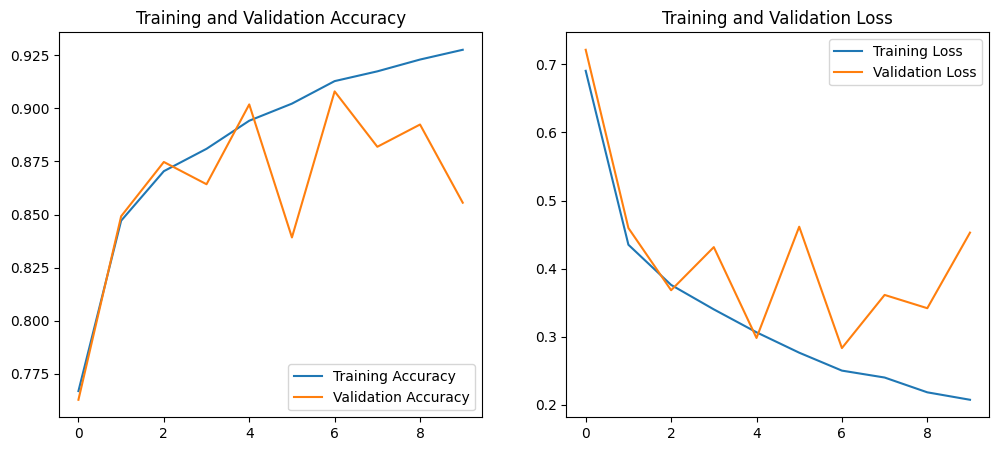

In [ ]:
# Visualize Training History
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend(loc='lower right')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend(loc='upper right')
    plt.show()

plot_history(history)